In [19]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
df = pd.read_csv('AB_NYC_2019[1].csv')

Saving AB_NYC_2019[1].csv to AB_NYC_2019[1] (1).csv


Saving AB_NYC_2019[1].csv to AB_NYC_2019[1] (2).csv
✅ File Loaded: AB_NYC_2019[1] (2).csv

First 5 rows:
     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_

/tmp/ipykernel_1516/2191112361.py:34: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['reviews_per_month'].fillna(0, inplace=True)


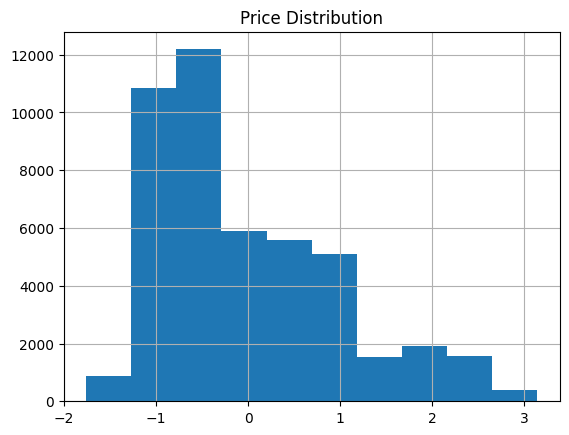

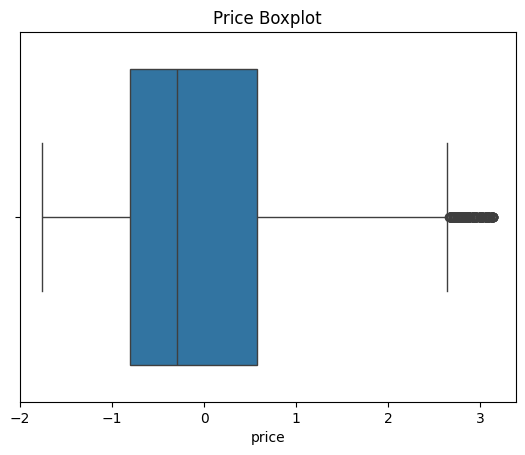

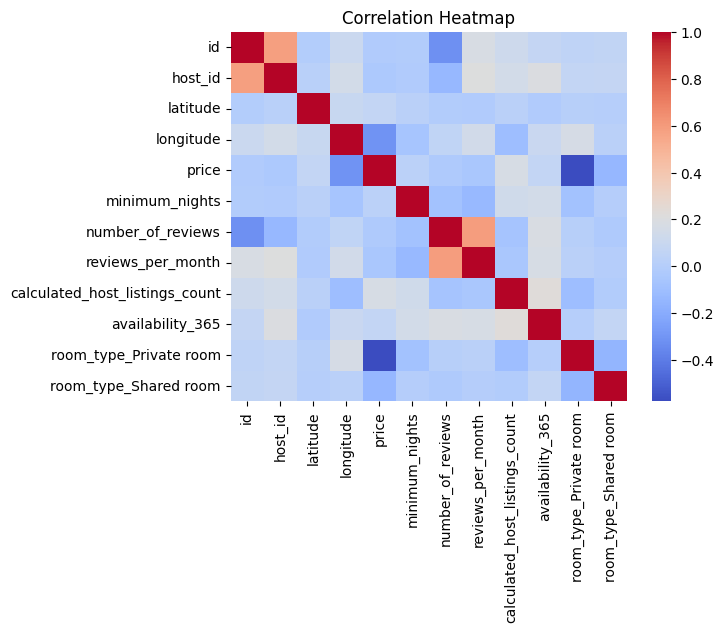


Final Dataset Shape: (45887, 18)
✅ Project Completed Successfully!


In [25]:
# ================================
# 📌 Airbnb Data Analysis Project
# ================================

# Step 0: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Upload & Load Dataset (BEST METHOD)
from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]   # auto-detect filename
df = pd.read_csv(file_name)

print("✅ File Loaded:", file_name)

# Step 2: Data Exploration
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

# Step 3: Handle Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

df['reviews_per_month'].fillna(0, inplace=True)
df.dropna(subset=['name', 'host_name'], inplace=True)

# Step 4: Outlier Detection (IQR)
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("\nLower Bound:", lower)
print("Upper Bound:", upper)

# Step 5: Outlier Treatment
df = df[(df['price'] >= lower) & (df['price'] <= upper)]

# Step 6: Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['price', 'minimum_nights', 'number_of_reviews']] = scaler.fit_transform(
    df[['price', 'minimum_nights', 'number_of_reviews']]
)

# Step 7: Encoding
df = pd.get_dummies(df, columns=['room_type'], drop_first=True)

# Step 8: Feature Engineering
df['price_category'] = pd.cut(df['price'], bins=3, labels=['Low', 'Medium', 'High'])

# Step 9: EDA

# Histogram
plt.figure()
df['price'].hist()
plt.title("Price Distribution")
plt.show()

# Boxplot
plt.figure()
sns.boxplot(x=df['price'])
plt.title("Price Boxplot")
plt.show()

# Heatmap
plt.figure()
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Step 10: Final Dataset
print("\nFinal Dataset Shape:", df.shape)

# Save cleaned dataset
df.to_csv('cleaned_airbnb.csv', index=False)

print("✅ Project Completed Successfully!")